# Метод роя частиц (PSO)

**Материалы доклада по курсу "Численные методы", прочитанного 25 апреля 2026 года.**

**Автор:** Ластовецкий Дмитрий, Университет ИТМО, институт математики.

Ноутбук содержит воспроизводимую реализацию Particle Swarm Optimization, набор экспериментов на выпуклой квадратичной функции и функции Растригина, а также графики для сравнения разных параметров запуска. Основная реализация алгоритма вынесена в `src/pso_core.py`, чтобы код можно было переиспользовать из скриптов и презентации.


## Формулы метода

На шаге $t\to t+1$ для частицы $i$:

$$
v_i^{t+1}=\omega v_i^t+c_1 r_{1,i}^t(p_i^t-x_i^t)+c_2 r_{2,i}^t(g^t-x_i^t),
$$

$$
x_i^{t+1}=\Pi_D(x_i^t+v_i^{t+1}).
$$

Здесь $p_i^t$ — лучшая точка самой частицы, $g^t$ — лучшая точка всего роя, $\Pi_D$ — обрезка по границам области. Значение $f(g^t)$ не возрастает, потому что мы храним лучший найденный результат за все прошедшие итерации.

In [1]:
from pathlib import Path
import sys
from time import perf_counter

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.pso_core import (
    PSOConfig,
    hitting_time,
    make_quadratic,
    make_rastrigin,
    pso,
    summarize_run,
)

## Функции

1. Сильно выпуклая квадратичная функция
$$
f_1(x)=\frac12(x_1^2+kx_2^2).
$$
При $k\ge 1$ матрица Гессе равна $\mathrm{diag}(1,k)$, поэтому функция $1$-сильно выпукла. Чем больше $k$, тем уже долина и тем хуже обусловленность.

2. Функция Растригина
$$
f_2(x)=An+\sum_{j=1}^n\left(x_j^2-A\cos(2\pi x_j)\right).
$$
У нее много локальных минимумов, поэтому старт и параметры влияют сильнее.

In [2]:
bounds_quad = np.array([[-4, 4], [-4, 4]], dtype=float)
bounds_rast = np.array([[-5.12, 5.12], [-5.12, 5.12]], dtype=float)

quad10 = make_quadratic(kappa=10)
quad100 = make_quadratic(kappa=100)
rast10 = make_rastrigin(amplitude=10)
rast20 = make_rastrigin(amplitude=20)

## Метрики скорости

Сравниваем не только финальное значение, но и скорость.

* $T_\varepsilon=\min\{t: f(g^t)-f^\star\le\varepsilon\}$ — сколько итераций нужно для достижения заданной точности.
* `runtime_ms` — среднее реальное время одного запуска алгоритма в миллисекундах.

Первая метрика показывает поведение самого алгоритма, вторая — практическую стоимость конкретной Python-реализации на текущей машине.


In [3]:
experiments = {
    'quadratic_baseline': {
        'name': 'Квадратичная: базовый запуск',
        'objective': quad10,
        'bounds': bounds_quad,
        'config': PSOConfig(n_particles=35, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=2),
    },
    'quadratic_small_swarm': {
        'name': 'Квадратичная: мало частиц',
        'objective': quad10,
        'bounds': bounds_quad,
        'config': PSOConfig(n_particles=8, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=2),
    },
    'quadratic_ill_conditioned': {
        'name': 'Квадратичная: k=100',
        'objective': quad100,
        'bounds': bounds_quad,
        'config': PSOConfig(n_particles=35, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=5),
    },
    'quadratic_slow': {
        'name': 'Квадратичная: слабое притяжение',
        'objective': quad10,
        'bounds': bounds_quad,
        'config': PSOConfig(n_particles=25, n_iter=120, omega=0.20, c1=0.35, c2=0.35, seed=9),
    },
    'rastrigin_baseline': {
        'name': 'Растригин: базовый запуск',
        'objective': rast10,
        'bounds': bounds_rast,
        'config': PSOConfig(n_particles=35, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=4),
    },
    'rastrigin_small_swarm': {
        'name': 'Растригин: мало частиц',
        'objective': rast10,
        'bounds': bounds_rast,
        'config': PSOConfig(n_particles=8, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=4),
    },
    'rastrigin_local_start': {
        'name': 'Растригин: старт около (3,3)',
        'objective': rast10,
        'bounds': bounds_rast,
        'config': PSOConfig(
            n_particles=12, n_iter=120, omega=0.25, c1=0.55, c2=0.55,
            seed=11, init_center=(3.0, 3.0), init_spread=0.06, velocity_scale=0.03,
        ),
    },
    'rastrigin_harder': {
        'name': 'Растригин: A=20',
        'objective': rast20,
        'bounds': bounds_rast,
        'config': PSOConfig(n_particles=35, n_iter=120, omega=0.72, c1=1.49, c2=1.49, seed=12),
    },
}

TIMED_RUNS = 20

for item in experiments.values():
    item['history'] = pso(item['objective'], item['bounds'], item['config'])
    start = perf_counter()
    for _ in range(TIMED_RUNS):
        pso(item['objective'], item['bounds'], item['config'])
    item['runtime_ms'] = (perf_counter() - start) * 1000 / TIMED_RUNS
    item['summary'] = summarize_run(item['history'], eps=1e-3)

In [4]:
import pandas as pd

rows = []
for item in experiments.values():
    cfg = item['config']
    s = item['summary']
    rows.append({
        'запуск': item['name'],
        'N': cfg.n_particles,
        'omega': cfg.omega,
        'c1': cfg.c1,
        'c2': cfg.c2,
        'final f': s['final_f'],
        'T_eps': s['hit_eps'],
        'runtime, ms': item['runtime_ms'],
        'best x': (round(s['best_x1'], 4), round(s['best_x2'], 4)),
    })
pd.DataFrame(rows)

,запуск,N,omega,c1,c2,final f,T_eps,"runtime, ms",best x
0,Квадратичная: базовый запуск,35,0.72,1.49,1.49,4.872622e-13,15.0,1.826263,"(0.0, -0.0)"
1,Квадратичная: мало частиц,8,0.72,1.49,1.49,3.630696e-12,25.0,1.671004,"(-0.0, 0.0)"
2,Квадратичная: k=100,35,0.72,1.49,1.49,5.426200e-15,24.0,3.373337,"(-0.0, 0.0)"
3,Квадратичная: слабое притяжение,25,0.20,0.35,0.35,8.806530e-08,16.0,1.827398,"(-0.0004, 0.0)"
4,Растригин: базовый запуск,35,0.72,1.49,1.49,8.881784e-14,26.0,2.226965,"(-0.0, 0.0)"
5,Растригин: мало частиц,8,0.72,1.49,1.49,9.949591e-01,NaN,2.008144,"(-0.995, 0.0)"
6,"Растригин: старт около (3,3)",12,0.25,0.55,0.55,1.790920e+01,NaN,2.001831,"(2.9849, 2.9849)"
7,Растригин: A=20,35,0.72,1.49,1.49,1.364832e-09,59.0,2.157400,"(0.0, -0.0)"


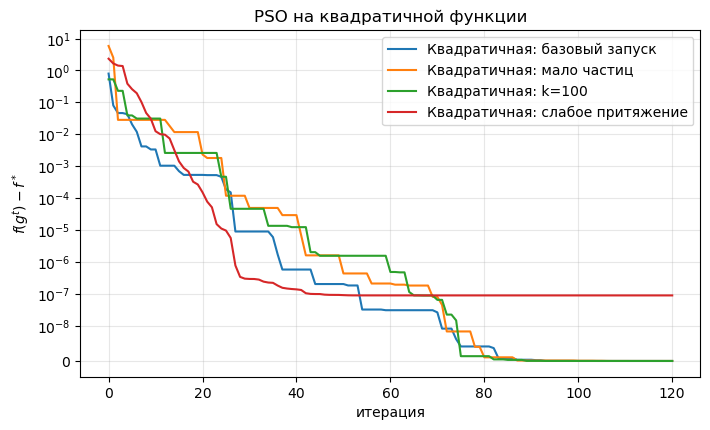

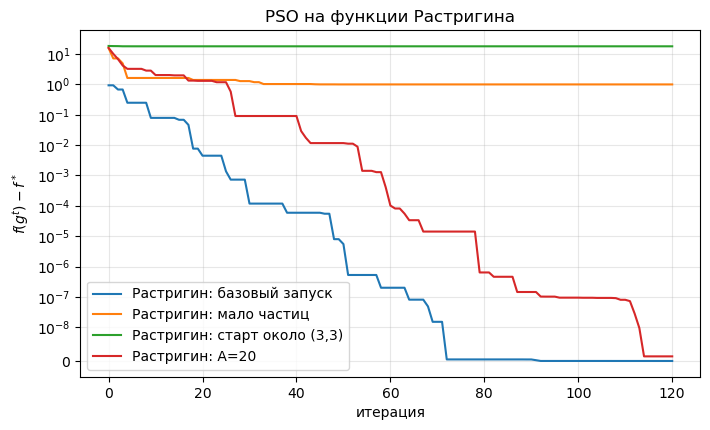

In [5]:
def plot_group(prefix, title):
    plt.figure(figsize=(8, 4.5))
    for key, item in experiments.items():
        if key.startswith(prefix):
            plt.plot(item['history']['best_values'], label=item['name'])
    plt.yscale('symlog', linthresh=1e-8)
    plt.xlabel('итерация')
    plt.ylabel('$f(g^t)-f^*$')
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_group('quadratic', 'PSO на квадратичной функции')
plot_group('rastrigin', 'PSO на функции Растригина')

## Почему некоторые запуски сходятся хуже

* Малый рой хуже покрывает область поиска. На Растригине это особенно заметно: частицы могут не попасть в окрестность глобального минимума.
* Слишком слабые коэффициенты $c_1,c_2$ и малая инерция дают маленькие шаги. Метод становится стабильным, но медленным.
* Старт всех частиц около одной локальной ямы на Растригине почти убирает глобальный поиск. Рой видит только небольшой фрагмент ландшафта.
* Увеличение $k$ в квадратичной функции делает долину уже: попасть точно в направление $x_2$ становится сложнее.


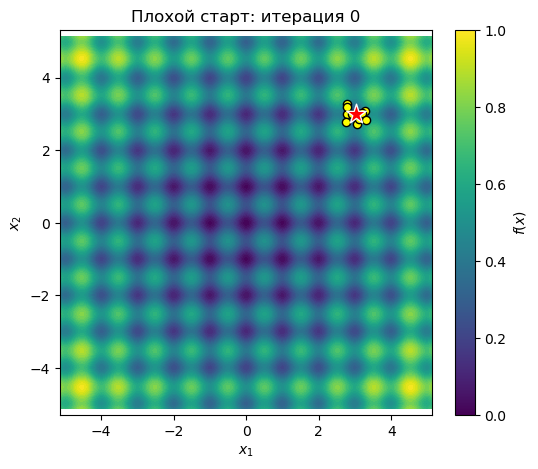

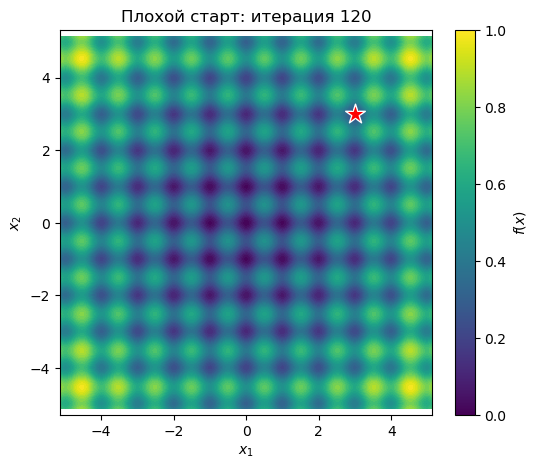

In [6]:
def plot_swarm(objective, history, lim, iteration, title):
    xs = np.linspace(-lim, lim, 250)
    ys = np.linspace(-lim, lim, 250)
    X, Y = np.meshgrid(xs, ys)
    Z = objective(np.stack([X, Y], axis=-1))
    plt.figure(figsize=(6, 5))
    plt.contourf(X, Y, Z, levels=45, cmap='viridis')
    P = history['positions'][iteration]
    G = history['best_positions'][iteration]
    plt.scatter(P[:, 0], P[:, 1], c='yellow', edgecolors='black', s=35)
    plt.scatter(G[0], G[1], marker='*', c='red', edgecolors='white', s=220)
    plt.title(f'{title}: итерация {iteration}')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.axis('equal')
    plt.colorbar(label='$f(x)$')
    plt.show()

plot_swarm(rast10, experiments['rastrigin_local_start']['history'], 5.12, 0, 'Плохой старт')
plot_swarm(rast10, experiments['rastrigin_local_start']['history'], 5.12, 120, 'Плохой старт')

## Главный вывод

PSO работает за счет памяти и случайного распределенного поиска: лучший найденный результат не теряется, а частицы пробуют новые точки вокруг личного и коллективного опыта. Но общий строгий темп сходимости для произвольной невыпуклой функции получить нельзя. Поэтому скорость честно оценивают экспериментально: кривыми $f(g^t)$, временем $T_\varepsilon$, временем запуска в миллисекундах и сравнением нескольких запусков.